In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]
import pandas as pd
import numpy as np

df = pd.read_csv(
    "adult(in).csv",
    sep=";",            # IMPORTANT: semicolon separator
    header=0,           # first row is header
    skipinitialspace=True
)

print("Shape:", df.shape)
df.head()


print("=" * 62)
print("  ADULT INCOME — ML PREPROCESSING PIPELINE")
print("=" * 62)
print(f"\n  Raw dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: (32561, 15)
  ADULT INCOME — ML PREPROCESSING PIPELINE

  Raw dataset shape : 32,561 rows × 15 columns


In [3]:
print("\n── Step 1 · Replace '?' with NaN ───────────────────────────")

df.replace("?", np.nan, inplace=True)

missing_before = df.isnull().sum()
affected_cols  = missing_before[missing_before > 0]
print(f"  Columns with missing values after replacement:")
for col, n in affected_cols.items():
    print(f"    {col:<20} {n:>5,} missing  ({n/len(df)*100:.1f}%)")


── Step 1 · Replace '?' with NaN ───────────────────────────
  Columns with missing values after replacement:
    workclass            1,836 missing  (5.6%)
    occupation           1,843 missing  (5.7%)
    native_country         583 missing  (1.8%)


In [4]:
print(df.head(3))
print("Unique sample from workclass:", df["workclass"].astype(str).unique()[:10])

   Age         workclass  final weight  education  education_num  \
0   39         State-gov         77516  Bachelors             13   
1   50  Self-emp-not-inc         83311  Bachelors             13   
2   38           Private        215646    HS-grad              9   

       marital_status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  <=50K  
Unique sample from workclass: <StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',             

In [5]:
print("\n── Step 2 · Drop rows with NaN ─────────────────────────────")

rows_before = len(df)
df.dropna(inplace=True)
rows_after  = len(df)
dropped     = rows_before - rows_after

print(f"  Rows before : {rows_before:,}")
print(f"  Rows dropped: {dropped:,}  ({dropped/rows_before*100:.1f}%)")
print(f"  Rows after  : {rows_after:,}")

# Verify no missing values remain
assert df.isnull().sum().sum() == 0, "Still has missing values!"
print("  ✓ No missing values remaining.")



── Step 2 · Drop rows with NaN ─────────────────────────────
  Rows before : 32,561
  Rows dropped: 2,399  (7.4%)
  Rows after  : 30,162
  ✓ No missing values remaining.


In [6]:
print("\n── Step 3 · One-Hot Encode Categorical Columns ─────────────")



── Step 3 · One-Hot Encode Categorical Columns ─────────────


In [7]:
df.drop(columns=["education", "final weight"], inplace=True)
print("  Dropped 'education' (redundant with education_num)")
print("  Dropped 'final weight'    (sampling weight, not predictive)")

  Dropped 'education' (redundant with education_num)
  Dropped 'final weight'    (sampling weight, not predictive)


In [8]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "income"]


C:\Users\dioni\AppData\Local\Temp\ipykernel_14900\1918753230.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [9]:
print(f"\n  Columns to encode: {cat_cols}")



  Columns to encode: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [10]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [11]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\n  Shape after encoding: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  New dummy columns created: {df.shape[1] - (13 - 2)} "
      f"(from {len(cat_cols)} categorical features)")



  Shape after encoding: 30,162 rows × 81 columns
  New dummy columns created: 70 (from 7 categorical features)


In [12]:
print("\n── Step 4 · Binary-encode Target Column (income) ──────────")

df["income"] = (df["income"].str.strip() == ">50K").astype(int)

counts = df["income"].value_counts()
print(f"  0  (<=50K) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  1  ( >50K) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print("  ✓ 'income' is now a binary integer column.")


── Step 4 · Binary-encode Target Column (income) ──────────
  0  (<=50K) : 22,654  (75.1%)
  1  ( >50K) : 7,508  (24.9%)
  ✓ 'income' is now a binary integer column.


In [13]:
print("\n── Step 5 · Train / Test Split ─────────────────────────────")


── Step 5 · Train / Test Split ─────────────────────────────


In [14]:
X = df.drop(columns=["income"])
y = df["income"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps class ratio identical in train & test
)

print(f"  Total samples : {len(X):,}")
print(f"  Training set  : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set      : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Features      : {X_train.shape[1]}")


  Total samples : 30,162
  Training set  : 24,129 rows  (80%)
  Test set      : 6,033  rows  (20%)
  Features      : 80


In [16]:
train_pos = y_train.mean() * 100
test_pos  = y_test.mean()  * 100
print(f"\n  Class balance (% >50K):")
print(f"    Train : {train_pos:.1f}%")
print(f"    Test  : {test_pos:.1f}%")
print("  ✓ Stratification confirmed — class ratios match.")


  Class balance (% >50K):
    Train : 24.9%
    Test  : 24.9%
  ✓ Stratification confirmed — class ratios match.


In [17]:
print("\n" + "=" * 62)
print("  PREPROCESSING COMPLETE — READY FOR MODELLING")
print("=" * 62)
print(f"""
  Objects available for modelling:
    X_train  — {X_train.shape[0]:,} × {X_train.shape[1]}  (training features)
    X_test   — {X_test.shape[0]:,}  × {X_test.shape[1]}  (test features)
    y_train  — {len(y_train):,}          (training labels)
    y_test   — {len(y_test):,}           (test labels)

  Feature list (first 10):
    {list(X_train.columns[:10])}
    ... and {X_train.shape[1] - 10} more.
""")


  PREPROCESSING COMPLETE — READY FOR MODELLING

  Objects available for modelling:
    X_train  — 24,129 × 80  (training features)
    X_test   — 6,033  × 80  (test features)
    y_train  — 24,129          (training labels)
    y_test   — 6,033           (test labels)

  Feature list (first 10):
    ['Age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov']
    ... and 70 more.



In [18]:
print("\n" + "=" * 55)
print("  ADULT INCOME — MODEL TRAINING & EVALUATION")
print("=" * 55)

print("\n── Baseline (Majority-Class Predictor) ─────────────────")



  ADULT INCOME — MODEL TRAINING & EVALUATION

── Baseline (Majority-Class Predictor) ─────────────────


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, classification_report
)

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [21]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
baseline_acc = accuracy_score(y_test, y_dummy)

In [22]:
print("\n── Step 1 · Logistic Regression ────────────────────────")


── Step 1 · Logistic Regression ────────────────────────


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False γιατί έχεις sparse/one-hot
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

lr.fit(X_train, y_train)
print("✓ Logistic Regression (scaled) trained.")


✓ Logistic Regression (scaled) trained.


In [24]:
print("\n── Step 2 · Random Forest + Grid Search ────────────────")



── Step 2 · Random Forest + Grid Search ────────────────


In [25]:
param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [10, 20, None],
    "min_samples_split": [2, 10],
}


In [26]:
rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=3, scoring="f1",
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

rf = grid_search.best_estimator_
print(f"\n  Best parameters  : {grid_search.best_params_}")
print(f"  Best CV F1-score : {grid_search.best_score_:.4f}")
print("  ✓ Random Forest trained.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

  Best parameters  : {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
  Best CV F1-score : 0.7128
  ✓ Random Forest trained.


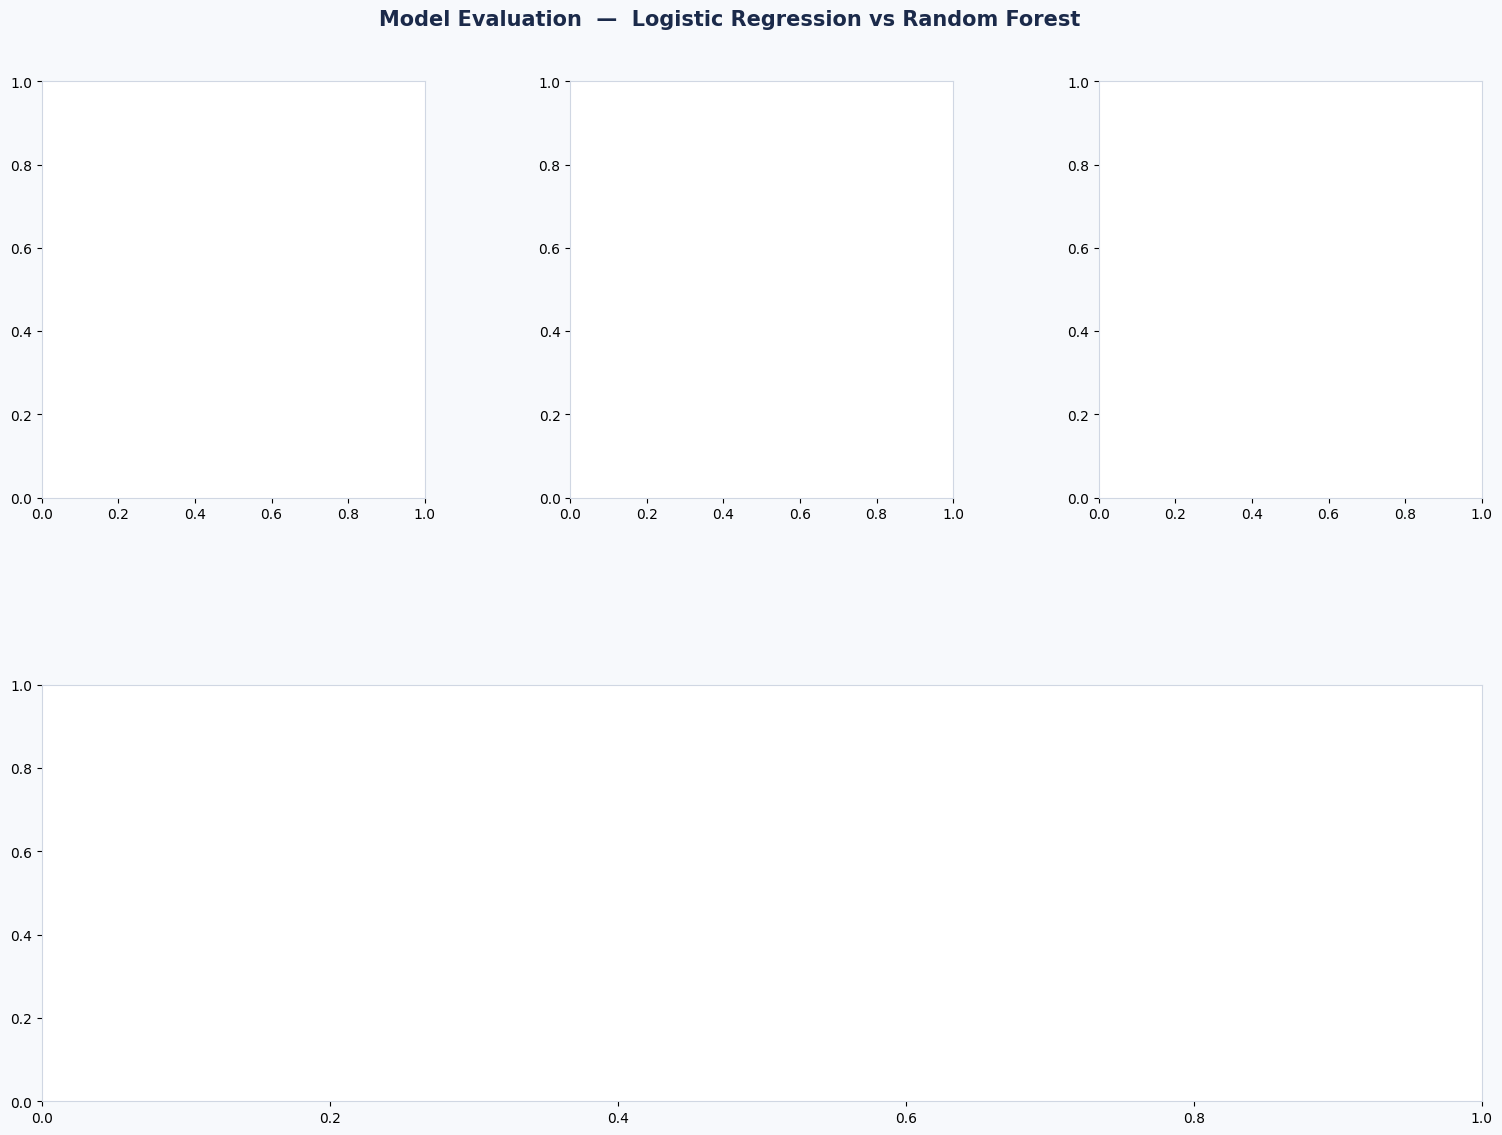

In [27]:
BG = "#F7F9FC"
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "Model Evaluation  —  Logistic Regression vs Random Forest",
    fontsize=15, fontweight="bold", color="#1B2A4A", y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
                       top=0.92, bottom=0.07, left=0.07, right=0.97)

ax_cm_lr  = fig.add_subplot(gs[0, 0])   # LR confusion matrix
ax_cm_rf  = fig.add_subplot(gs[0, 1])   # RF confusion matrix
ax_roc    = fig.add_subplot(gs[0, 2])   # ROC curves (both models)
ax_bar    = fig.add_subplot(gs[1, :])   # Summary bar chart

for ax in (ax_cm_lr, ax_cm_rf, ax_roc, ax_bar):
    ax.set_facecolor("white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#D0D7E3")

In [28]:
ax_roc.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random (AUC=0.500)")
ax_roc.set_title("ROC Curves", fontweight="bold", color="#1B2A4A")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1.02])

(0.0, 1.02)

In [29]:
# Evaluate both models

In [30]:
def evaluate(name, model, X_te, y_te, colour, ax_cm, ax_roc, results):

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    }

    print(f"\n{name}")
    print("Accuracy:", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall:", round(rec,4))
    print("F1:", round(f1,4))
    print("ROC-AUC:", round(auc,4))

    cm = confusion_matrix(y_te, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax_cm
    )

    ax_cm.set_title(name + " Confusion Matrix")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

In [31]:
BG   = "#F7F9FC"
C_LR = "#4C72B0"
C_RF = "#DD8452"
C_BL = "#8C8C8C"

In [32]:
results = {}

In [33]:
print("\n" + "=" * 55)
print("  EVALUATION RESULTS")
print("=" * 55)

evaluate("Logistic Regression", lr, X_test, y_test, C_LR, ax_cm_lr, ax_roc, results)
evaluate("Random Forest",        rf, X_test, y_test, C_RF, ax_cm_rf, ax_roc, results)

ax_roc.legend(fontsize=9, loc="lower right", framealpha=0.8)



  EVALUATION RESULTS

Logistic Regression
Accuracy: 0.8052
Precision: 0.5762
Recall: 0.8229
F1: 0.6778
ROC-AUC: 0.9016

Random Forest
Accuracy: 0.8493
Precision: 0.6766
Recall: 0.7563
F1: 0.7142
ROC-AUC: 0.912


In [34]:
# Summary bar chart — side-by-side metric comparison

In [35]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

In [36]:
etrics    = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
lr_scores  = [results["Logistic Regression"][m] for m in metrics]
rf_scores  = [results["Random Forest"][m]        for m in metrics]

x     = np.arange(len(metrics))
width = 0.28

bars_bl = ax_bar.bar(x - width,   [baseline_acc] + [0]*4,  width, label="Baseline",            color=C_BL, alpha=0.75)
bars_lr = ax_bar.bar(x,            lr_scores,               width, label="Logistic Regression", color=C_LR, alpha=0.90)
bars_rf = ax_bar.bar(x + width,    rf_scores,               width, label="Random Forest",       color=C_RF, alpha=0.90)

# Annotate each bar with its value
for bar_group in (bars_bl, bars_lr, bars_rf):
    for bar in bar_group:
        h = bar.get_height()
        if h > 0.01:
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8, color="#1B2A4A"
            )

ax_bar.set_title("Metric Comparison  —  All Models", fontweight="bold", color="#1B2A4A", pad=10)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics, fontsize=11)
ax_bar.set_ylabel("Score")
ax_bar.set_ylim(0, 1.12)
ax_bar.legend(loc="upper right", framealpha=0.8)
ax_bar.axhline(baseline_acc, color=C_BL, linestyle=":", lw=1.4, alpha=0.7)
fig.savefig("model_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()


In [37]:
# Save figure

In [38]:
# Final printed summary table

In [39]:
print("\n" + "=" * 55)
print("  FINAL SUMMARY TABLE")
print("=" * 55)

summary = pd.DataFrame(results).T
summary.index.name = "Model"
summary = summary.round(4)
# Add baseline row (only accuracy is meaningful for a dummy classifier)
summary.loc["Baseline (Majority)"] = [baseline_acc, np.nan, np.nan, np.nan, np.nan]
print(summary.to_string())

print("\n" + "=" * 55)
print("  KEY TAKEAWAYS")
print("=" * 55)

best_f1_model = max(results, key=lambda m: results[m]["F1"])
best_auc_model = max(results, key=lambda m: results[m]["AUC"])

print(f"""
  • Baseline accuracy : {baseline_acc:.4f}  (always predicts <=50K)
  • Best F1-score     : {results[best_f1_model]['F1']:.4f}  ({best_f1_model})
  • Best ROC-AUC      : {results[best_auc_model]['AUC']:.4f}  ({best_auc_model})

  Both models substantially outperform the naive baseline.
  For imbalanced targets, prefer F1 and AUC over raw accuracy.
""")



  FINAL SUMMARY TABLE
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression  0.805200     0.5762  0.8229  0.6778  0.9016
Random Forest        0.849300     0.6766  0.7563  0.7142  0.9120
Baseline (Majority)  0.751036        NaN     NaN     NaN     NaN

  KEY TAKEAWAYS

  • Baseline accuracy : 0.7510  (always predicts <=50K)
  • Best F1-score     : 0.7142  (Random Forest)
  • Best ROC-AUC      : 0.9120  (Random Forest)

  Both models substantially outperform the naive baseline.
  For imbalanced targets, prefer F1 and AUC over raw accuracy.



Top 15 Most Important Features:

                              feature  importance
0                                 Age    0.166949
12  marital_status_Married-civ-spouse    0.129083
1                       education_num    0.119691
2                        capital_gain    0.094147
4                      hours_per_week    0.085583
14       marital_status_Never-married    0.068322
39                           sex_Male    0.032445
30         relationship_Not-in-family    0.032136
3                        capital_loss    0.029725
32             relationship_Own-child    0.024502
19         occupation_Exec-managerial    0.022429
25          occupation_Prof-specialty    0.018893
33             relationship_Unmarried    0.017583
23           occupation_Other-service    0.015749
34                  relationship_Wife    0.014811


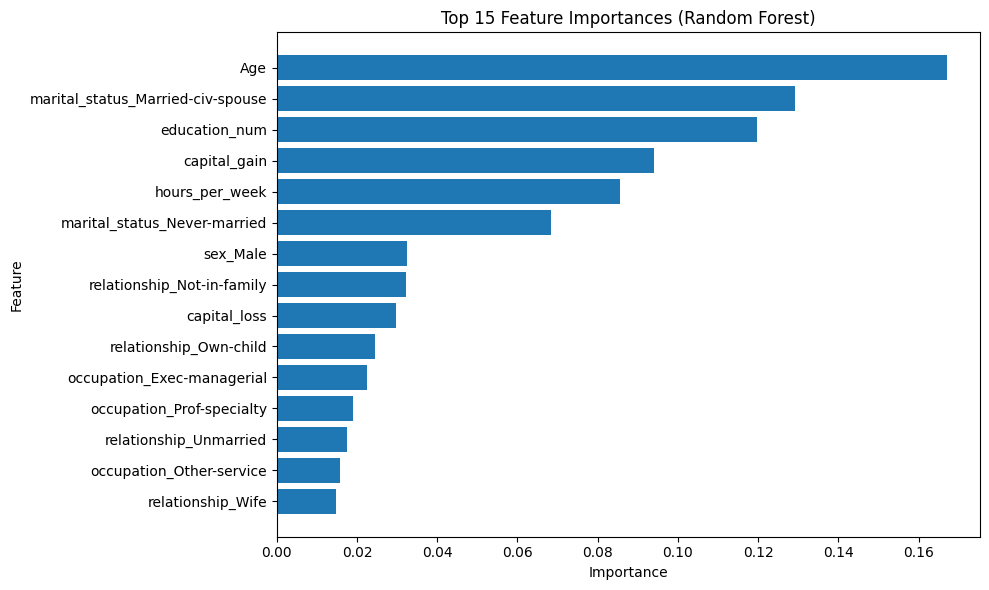

In [40]:
# Feature Importance from Random Forest

import pandas as pd
import matplotlib.pyplot as plt

# παίρνουμε τη σημασία των χαρακτηριστικών
importances = rf.feature_importances_

# ονόματα χαρακτηριστικών
feature_names = X_train.columns

# δημιουργία dataframe
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# ταξινόμηση
fi = fi.sort_values("importance", ascending=False)

print("Top 15 Most Important Features:\n")
print(fi.head(15))

# plot
plt.figure(figsize=(10,6))
plt.barh(fi.head(15)["feature"][::-1], fi.head(15)["importance"][::-1])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

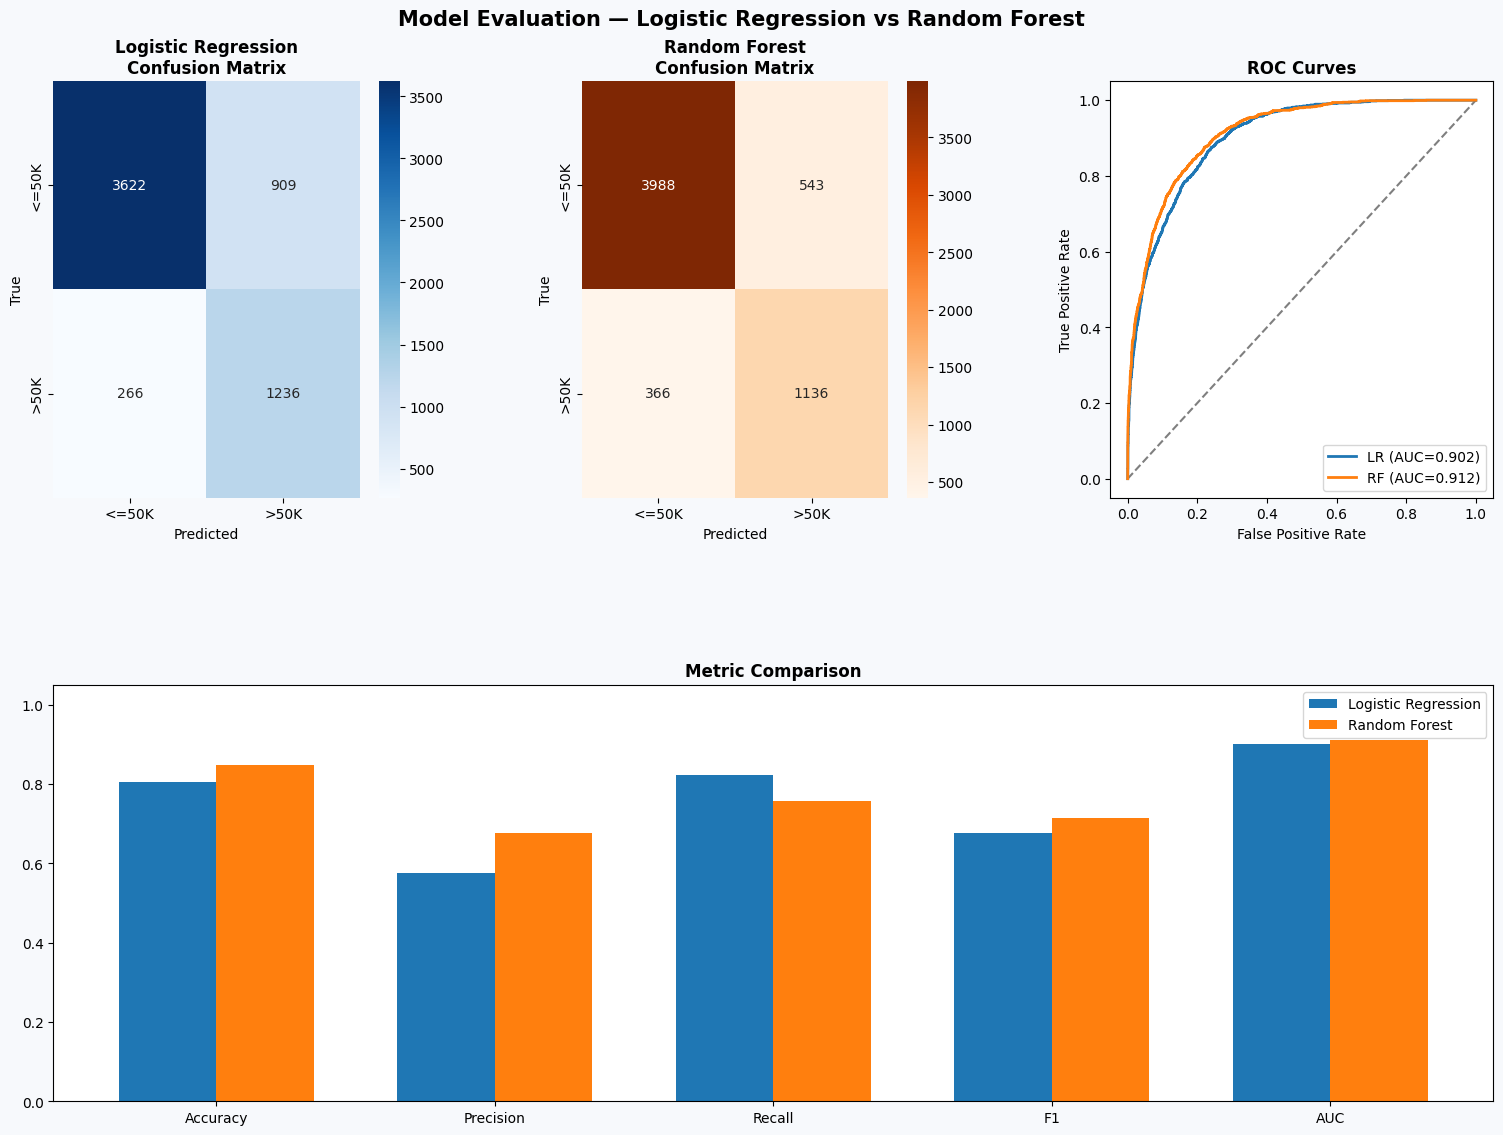

Saved: model_evaluation.png


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
assert "lr" in globals() and "rf" in globals(), "Δεν υπάρχουν lr/rf. Τρέξε πρώτα τα cells που κάνουν training."
assert "X_test" in globals() and "y_test" in globals(), "Δεν υπάρχουν X_test/y_test. Τρέξε πρώτα preprocessing + split."

BG   = "#F7F9FC"
C_LR = "#4C72B0"
C_RF = "#DD8452"

def eval_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:,1] if hasattr(model, "predict_proba") else None
    return {
        "acc": accuracy_score(y, y_pred),
        "prec": precision_score(y, y_pred, zero_division=0),
        "rec": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "auc": roc_auc_score(y, y_proba) if y_proba is not None else np.nan,
        "pred": y_pred,
        "proba": y_proba,
    }

lr_r = eval_model(lr, X_test, y_test)
rf_r = eval_model(rf, X_test, y_test)

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(BG)
fig.suptitle("Model Evaluation — Logistic Regression vs Random Forest", fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38, top=0.92, bottom=0.07, left=0.07, right=0.97)
ax_cm_lr = fig.add_subplot(gs[0, 0])
ax_cm_rf = fig.add_subplot(gs[0, 1])
ax_roc   = fig.add_subplot(gs[0, 2])
ax_bar   = fig.add_subplot(gs[1, :])

labels = ["<=50K", ">50K"]

# Confusion matrices
sns.heatmap(confusion_matrix(y_test, lr_r["pred"]), annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax_cm_lr)
ax_cm_lr.set_title("Logistic Regression\nConfusion Matrix", fontweight="bold")
ax_cm_lr.set_xlabel("Predicted")
ax_cm_lr.set_ylabel("True")

sns.heatmap(confusion_matrix(y_test, rf_r["pred"]), annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels, ax=ax_cm_rf)
ax_cm_rf.set_title("Random Forest\nConfusion Matrix", fontweight="bold")
ax_cm_rf.set_xlabel("Predicted")
ax_cm_rf.set_ylabel("True")

# ROC
ax_roc.plot([0,1],[0,1],"k--", alpha=0.5)
if lr_r["proba"] is not None:
    fpr,tpr,_ = roc_curve(y_test, lr_r["proba"])
    ax_roc.plot(fpr, tpr, lw=2, label=f"LR (AUC={lr_r['auc']:.3f})")
if rf_r["proba"] is not None:
    fpr,tpr,_ = roc_curve(y_test, rf_r["proba"])
    ax_roc.plot(fpr, tpr, lw=2, label=f"RF (AUC={rf_r['auc']:.3f})")
ax_roc.set_title("ROC Curves", fontweight="bold")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

# Metric comparison bar chart
metrics = ["acc","prec","rec","f1","auc"]
lr_scores = [lr_r[m] for m in metrics]
rf_scores = [rf_r[m] for m in metrics]
x = np.arange(len(metrics))
w = 0.35
ax_bar.bar(x - w/2, lr_scores, w, label="Logistic Regression")
ax_bar.bar(x + w/2, rf_scores, w, label="Random Forest")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(["Accuracy","Precision","Recall","F1","AUC"])
ax_bar.set_ylim(0, 1.05)
ax_bar.set_title("Metric Comparison", fontweight="bold")
ax_bar.legend()

fig.savefig("model_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: model_evaluation.png")